# Multivariate Analysis
-  2 or more variable

## Load the data
- Here I load the pickle file that was saved in step1

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# We load the pickle file so we have the correct data type

df = pd.read_pickle('data_MPG_clean.pkl')

In [3]:
# print 10 sample values

print(df.sample(10))

          mpg  cylinders  displacement  horsepower  weight  acceleration  \
153  18.00000          6           250         105    3459     16.000000   
167  29.00000          4            97          75    2171     16.000000   
117  29.00000          4            68          49    1867     19.500000   
242  21.50000          4           121         110    2600     12.796875   
396  28.00000          4           120          79    2625     18.593750   
370  31.00000          4           112          85    2575     16.203125   
316  19.09375          6           225          90    3381     18.703125   
141  29.00000          4            98          83    2219     16.500000   
139  14.00000          8           302         140    4638     16.000000   
115  15.00000          8           350         145    4082     13.000000   

     model_year  origin  
153          75     usa  
167          75   japan  
117          73  europe  
242          77  europe  
396          82     usa  
370    

In [4]:
# lets see data types and memory usage

print(df.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           398 non-null    float16 
 1   cylinders     398 non-null    uint8   
 2   displacement  398 non-null    int16   
 3   horsepower    398 non-null    uint8   
 4   weight        398 non-null    int16   
 5   acceleration  398 non-null    float16 
 6   model_year    398 non-null    int8    
 7   origin        398 non-null    category
dtypes: category(1), float16(2), int16(2), int8(1), uint8(2)
memory usage: 5.0 KB
None


In [5]:
# Display the descriptive stats

print(df.describe())

              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  398.000000   398.000000   
mean    23.515625    5.454774    193.424623  104.462312  2970.424623   
std      7.816406    1.701004    104.271000   38.199230   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   76.000000  2223.750000   
50%     23.000000    4.000000    148.500000   95.000000  2803.500000   
75%     29.000000    8.000000    262.000000  125.000000  3608.000000   
max     46.593750    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    398.000000  398.000000  
mean      15.570312   76.010050  
std        2.757812    3.697627  
min        8.000000   70.000000  
25%       13.822266   73.000000  
50%       15.500000   76.000000  
75%       17.175781   79.000000  
max       24.796875   82.000000  


**Multivariate Analysis**

* Pair plots between `mpg`, `weight`, `horsepower`, `displacement`, `acceleration`.
* Heatmap of correlation matrix to identify strongest relationships.
* Groupby analysis:

  * Mean mpg by `origin` and `cylinders`.
  * Mean mpg trend over years.

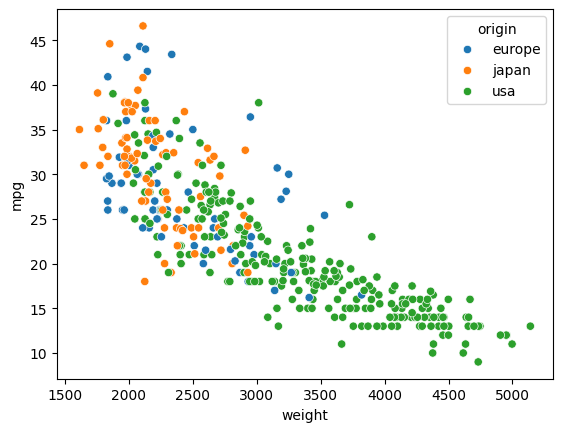

In [6]:
# mpg vs weight vs origin

sns.scatterplot(
    data=df,
    x='weight',
    y='mpg',
    hue='origin', # Generally hue is for categorical values
)

plt.show()

# observ: There is more from USA than Japan and Europe
# Cars from USA weigh more than Japan + Europe
# As weight goes up, MPG goes down

# Pairwise Multivariate Relationships (Pairplot)

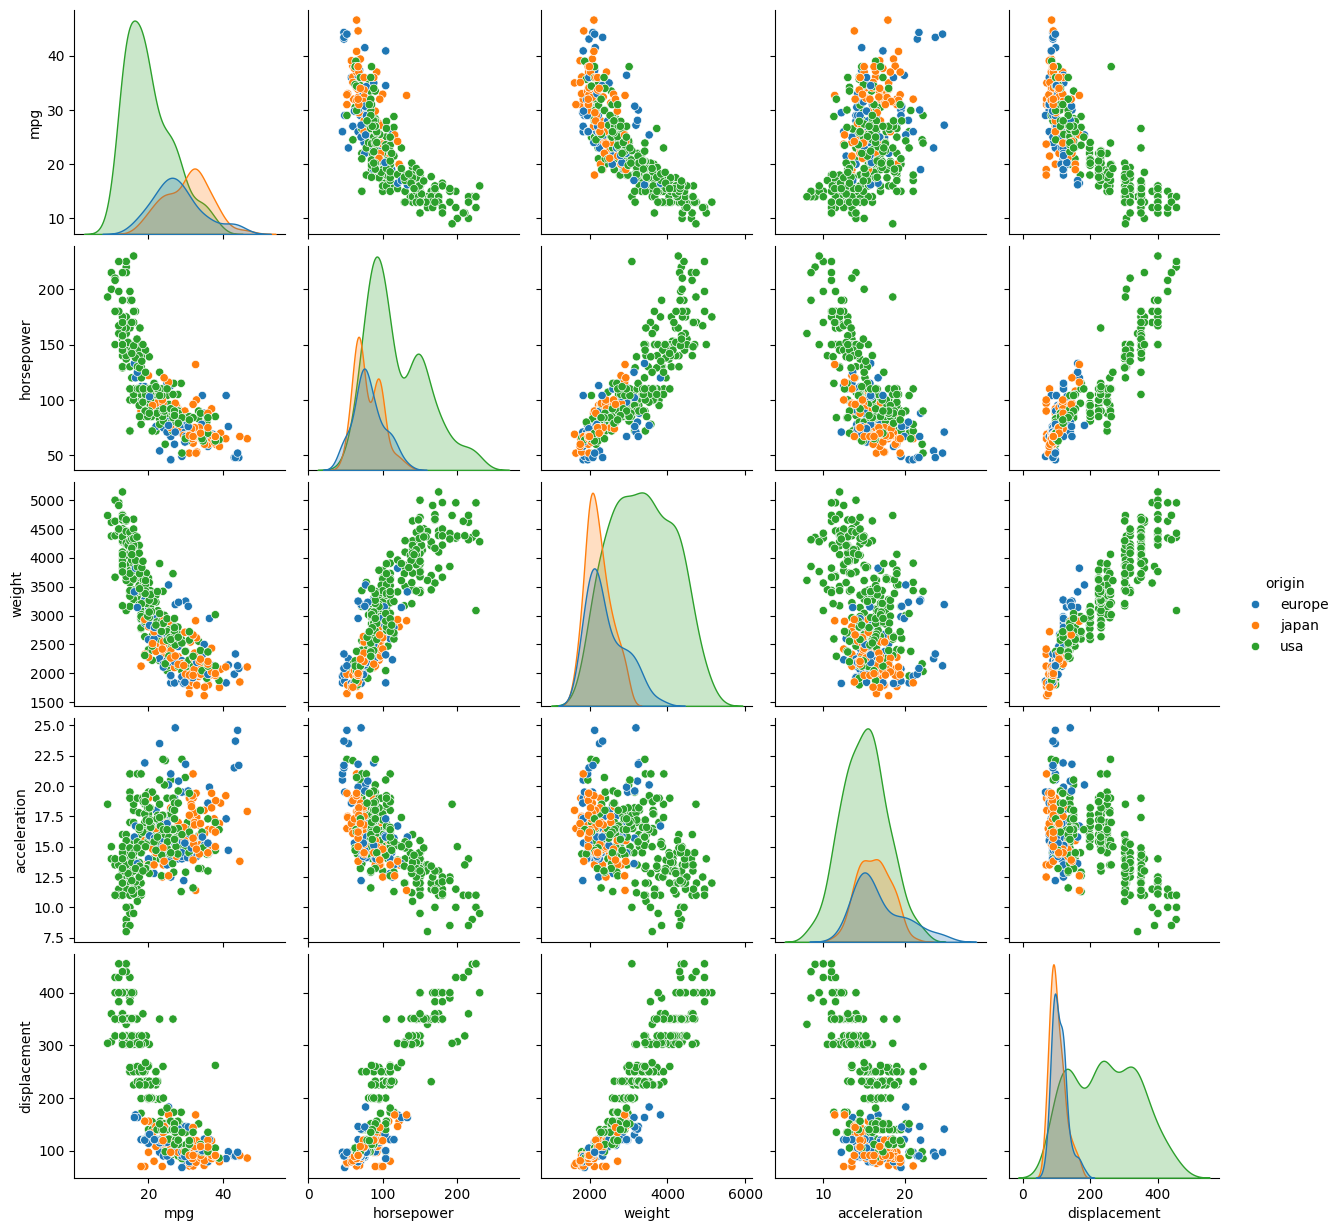

In [7]:
# NOTE: This may take 10 + secods becuase it is plotting 5x5=25 plots
sns.pairplot(
    data=df,
    vars=["mpg", "horsepower", "weight", "acceleration", "displacement"],
    hue="origin",
    diag_kind="kde"
)
plt.show()

# Observ: MPG decreases as weight and horsepower increase
# Cars from different origins cluster differently
# Useful for feature intuition before modeling

# Scatter (3 Variables)

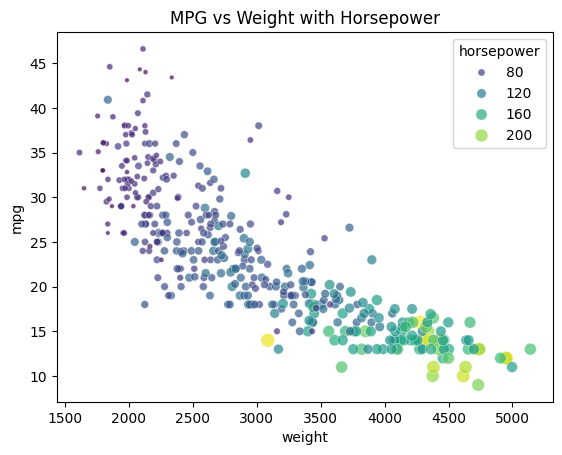

In [8]:
# MPG vs Weight vs Horsepower

sns.scatterplot(
    data=df,
    x="weight",
    y="mpg",
    hue="horsepower",
    size="horsepower",
    palette="viridis",
    # sizes=(20, 200),
    sizes=(10, 100),
    alpha=0.7
)
plt.title("MPG vs Weight with Horsepower")
plt.show()

# Observ: Car with low HP, have less weight and give high MPG

# Categorical + Numerical Multivariate Analysis

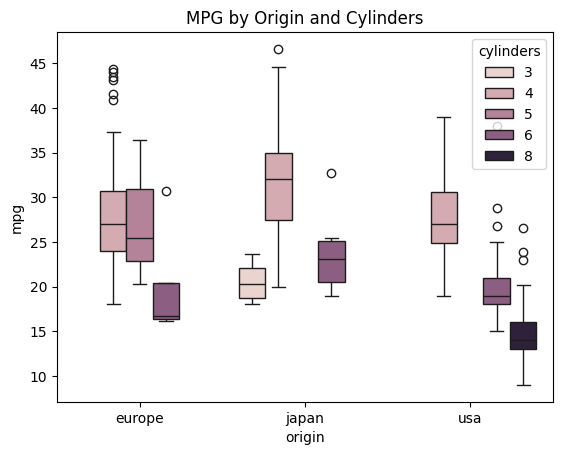

In [9]:
# TODO: Change the color to something more noticable
# MPG by Origin & Cylinders

sns.boxplot(
    data=df,
    x="origin",
    y="mpg",
    hue="cylinders" # It categorical in nature
)
plt.title("MPG by Origin and Cylinders")
plt.show()

# observ: Fewer cylinders → higher MPG

# Faceted Multivariate Analysis (Small Multiples)

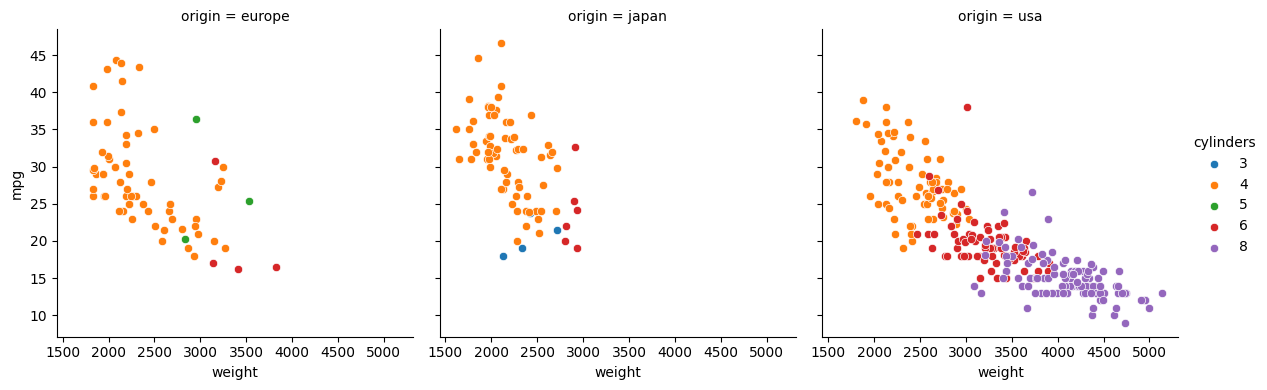

In [10]:
# origin vs cylinders vs weight vs mpg

g = sns.FacetGrid(
    data=df,
    col="origin",
    hue="cylinders",
    height=4,
    aspect=1
)
g.map(sns.scatterplot, "weight", "mpg")
g.add_legend()
plt.show()

# observ: USA does not have 3 clinder or 5 cylinders carts
# Japanese cars do not have 5 cylinders

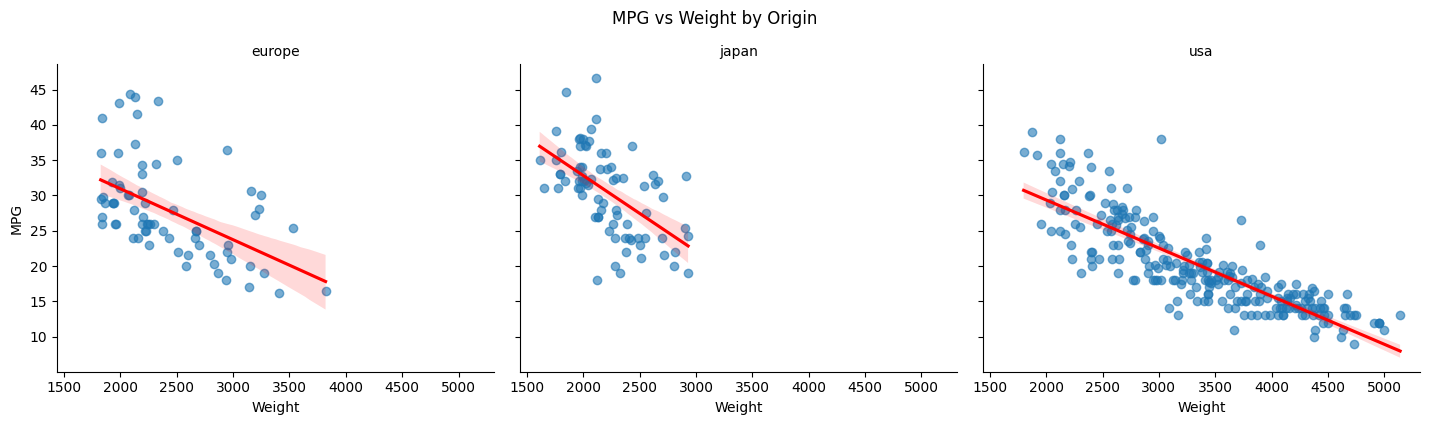

In [11]:
# Linear regression line

g = sns.FacetGrid(
    data=df,
    col="origin",
    height=4,
    aspect=1.2,
    sharex=True,
    sharey=True
)

g.map(
    sns.regplot,
    "weight",
    "mpg",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

g.set_axis_labels("Weight", "MPG")
g.set_titles(col_template="{col_name}")
g.fig.suptitle("MPG vs Weight by Origin", y=1.05)

plt.show()

Mean grouped value of MPG:
 origin  cylinders
europe  4            28.410000
        5            27.370001
        6            20.100000
japan   3            20.549999
        4            31.600000
        6            23.879999
usa     4            27.840000
        6            19.660000
        8            14.960000
Name: mpg, dtype: float32
+++++++



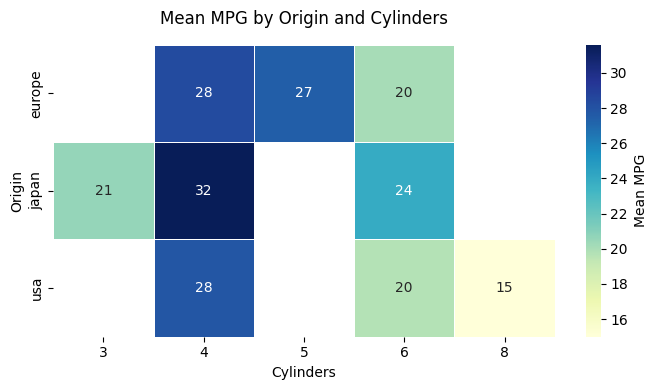

In [12]:
# Group by origin and cylinders, then take mean mpg
grouped = (
    df.groupby(["origin", "cylinders"], observed=True)["mpg"]
      .mean()
      .round(2)
)

print("Mean grouped value of MPG:\n", grouped)
print("+++++++\n")

# Pivot table (clean version)
pivot_table = df.pivot_table(
    values="mpg",
    index="origin",
    columns="cylinders",
    aggfunc="mean",
    observed=True
).round(1)

# Plot heatmap
plt.figure(figsize=(7, 4))
sns.heatmap(
    pivot_table,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Mean MPG"}
)

plt.title("Mean MPG by Origin and Cylinders", pad=15)
plt.xlabel("Cylinders")
plt.ylabel("Origin")
plt.tight_layout()
plt.show()

# observ: The 4 cylinder cars from Japan give best average of MPG
# The USA cars with 8 cylinders gives the lowest MPG

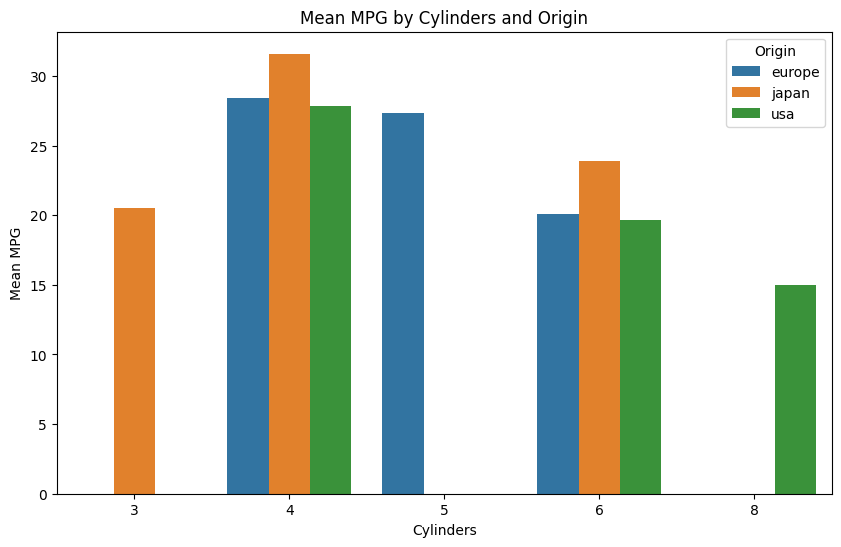

In [13]:
# grouped barplot is great for comparing mpg across cylinder counts, broken down by origin.
plt.figure(figsize=(10,6))
sns.barplot(x="cylinders", y="mpg", hue="origin", data=df, estimator="mean", errorbar=None)

plt.title("Mean MPG by Cylinders and Origin")
plt.xlabel("Cylinders")
plt.ylabel("Mean MPG")
plt.legend(title="Origin")
plt.show()

# observ: No data for 3 cyl cars from USA and Europe
# No data for 5 cyl cars from USA and Japan
# No data for 8 cyl cars from Europe and Japan

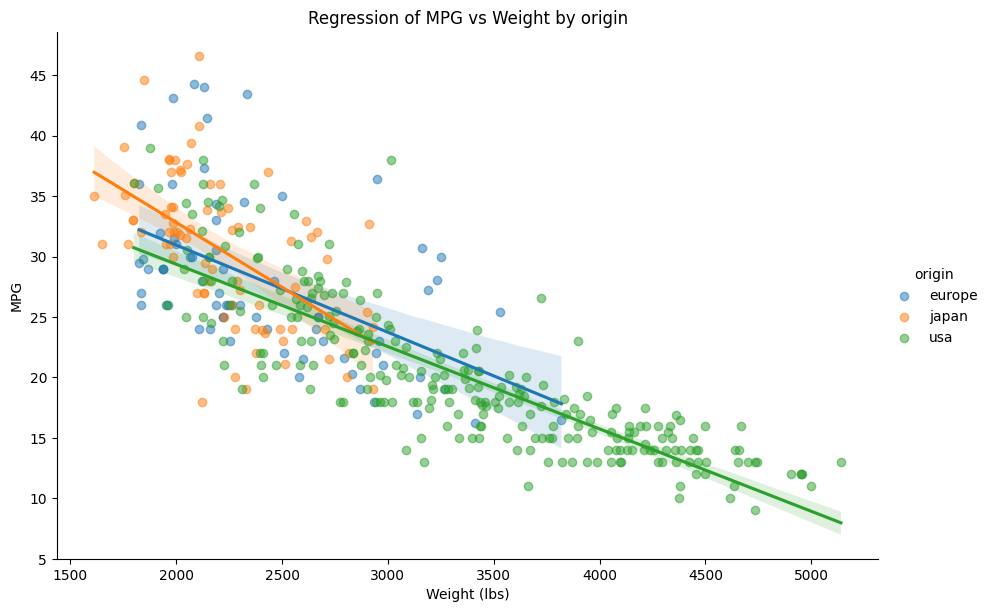

In [15]:
# Compare MPG vs Weight slopes across cylinders/origiin

# Regression with separate slopes for each cylinder group
hue_col = "origin" # or use origin, cylinders
sns.lmplot(data=df,
    x="weight", y="mpg",
    hue=hue_col, 
    aspect=1.5, 
    height=6, scatter_kws={"alpha":0.5})

plt.title(f"Regression of MPG vs Weight by {hue_col}")
plt.xlabel("Weight (lbs)")
plt.ylabel("MPG")
plt.show()


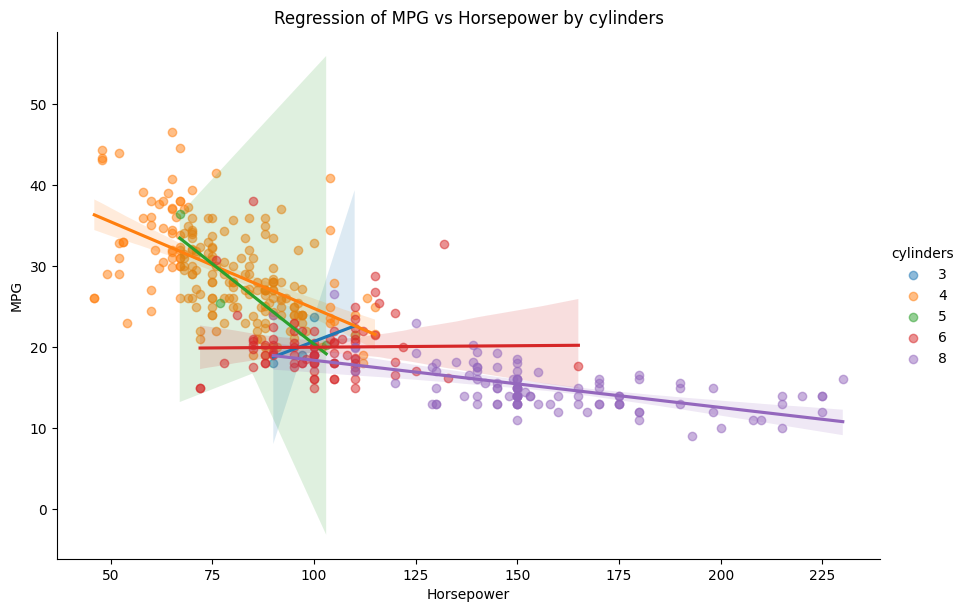

In [19]:

hue_col = "cylinders" # or use origin, cylinders
sns.lmplot(
    data=df,
    x="horsepower", y="mpg",
    hue=hue_col,
    aspect=1.5, height=6, scatter_kws={"alpha":0.5},
    palette="tab10"
)

plt.title(f"Regression of MPG vs Horsepower by {hue_col}")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()

# Observ: For 3 cylinder cars from Japan, as horsepower increases, MPG also increases

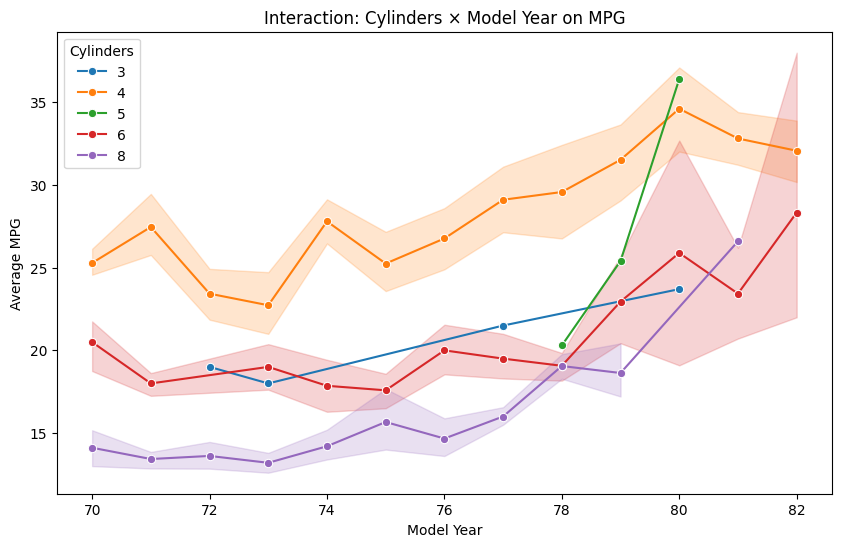

In [18]:
# step1: Interaction: Cylinders × Model Year on MPG
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df,
    x="model_year",
    y="mpg",
    hue="cylinders",
    estimator="mean",
    marker="o",
    palette="tab10"
)

plt.title("Interaction: Cylinders × Model Year on MPG")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.legend(title="Cylinders")
plt.show()

# Some values are overlapping....giving me headache...

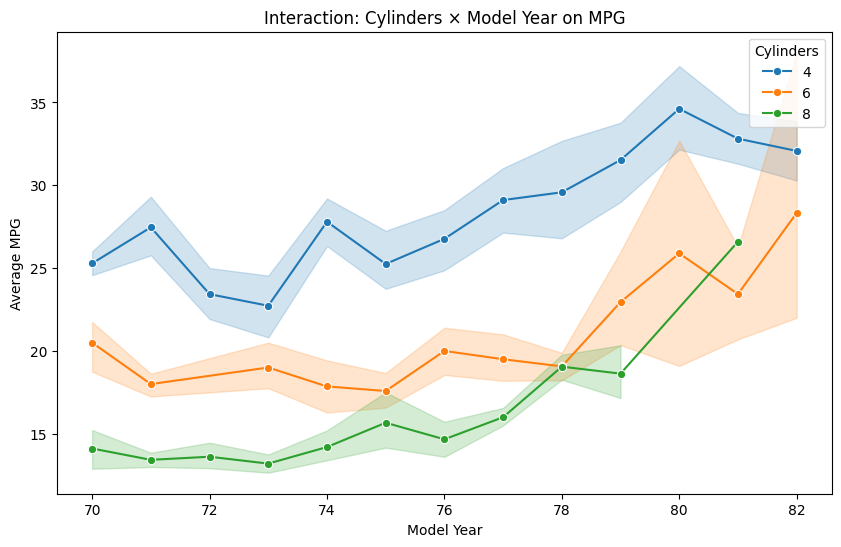

In [20]:
# step2: Perform filtering. Do only those that are visible with cylinder 4, 6, 8
mask = (df["cylinders"] == 8) | (df["cylinders"] == 6) | (df["cylinders"] == 4)

plt.figure(figsize=(10,6))
sns.lineplot(
    x="model_year", y="mpg", 
    hue="cylinders", 
    data=df[mask], 
    estimator="mean", marker="o",
    palette="tab10"
)

plt.title("Interaction: Cylinders × Model Year on MPG")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.legend(title="Cylinders")
plt.show()

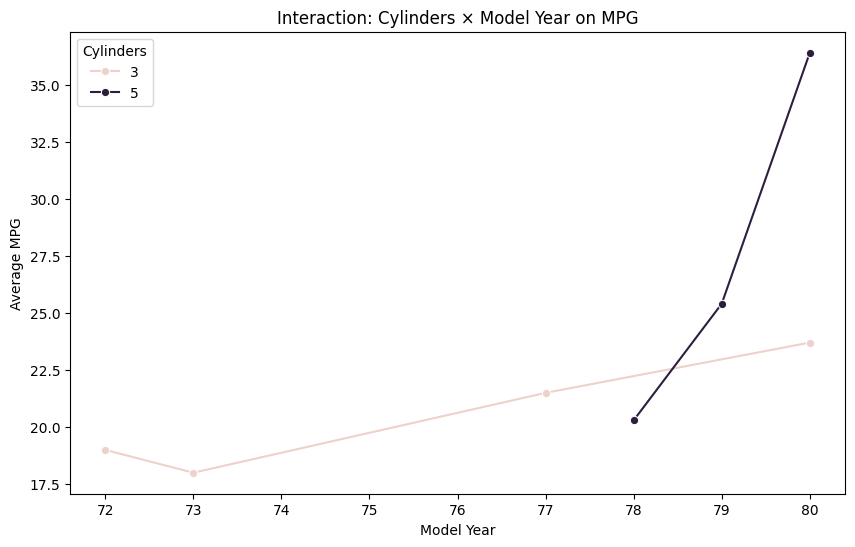

In [51]:
# step3: Perform filtering. Lets do the remaining ones with cylinder 3 and 5
mask = (df["cylinders"] == 3) | (df["cylinders"] == 5)

plt.figure(figsize=(10,6))
sns.lineplot(x="model_year", y="mpg", hue="cylinders", data=df[mask], estimator="mean", marker="o")

plt.title("Interaction: Cylinders × Model Year on MPG")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.legend(title="Cylinders")
plt.show()

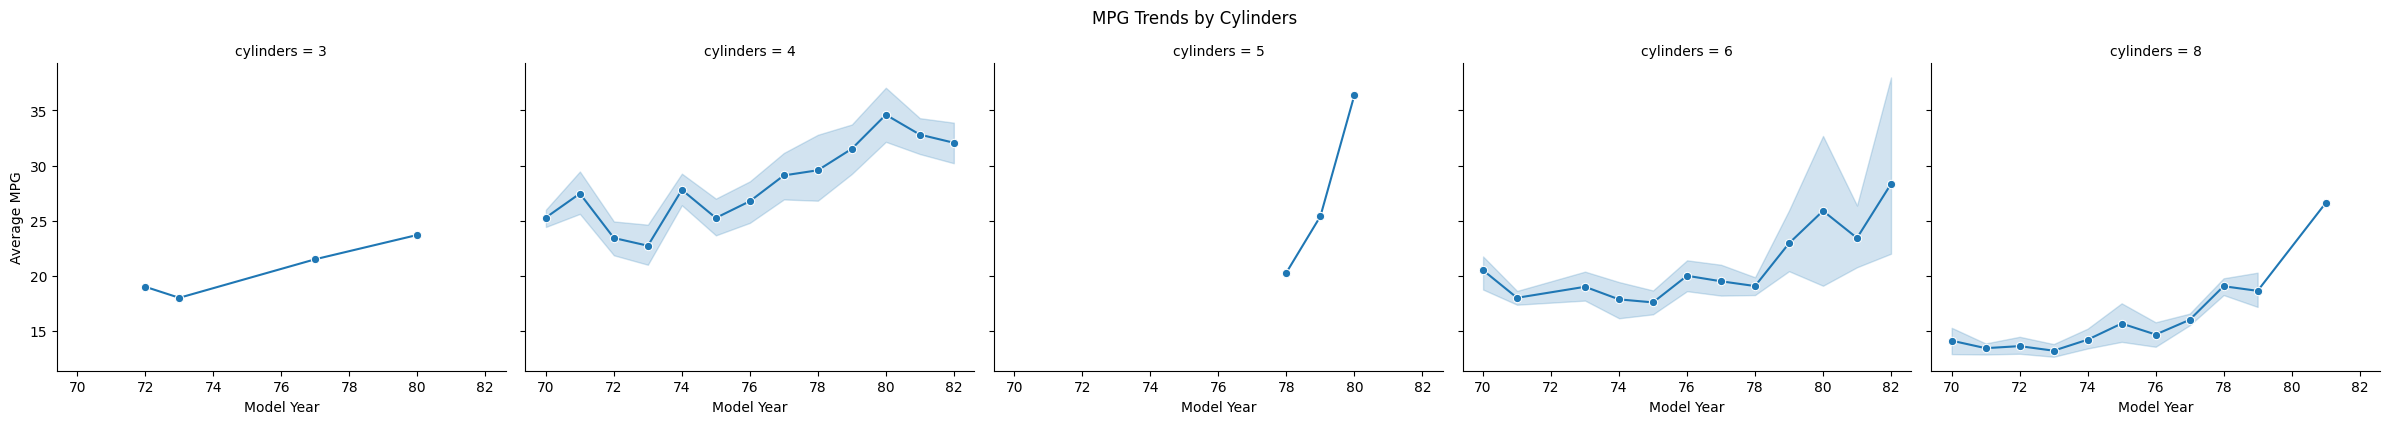

In [52]:
#step4: Lets do facetgrid
g = sns.FacetGrid(df, col="cylinders", height=4, aspect=1.2)
g.map(sns.lineplot, "model_year", "mpg", estimator="mean", marker="o")
g.set_axis_labels("Model Year", "Average MPG")
g.fig.suptitle("MPG Trends by Cylinders", y=1.05)
plt.show()

# observation: This plot is better than above.

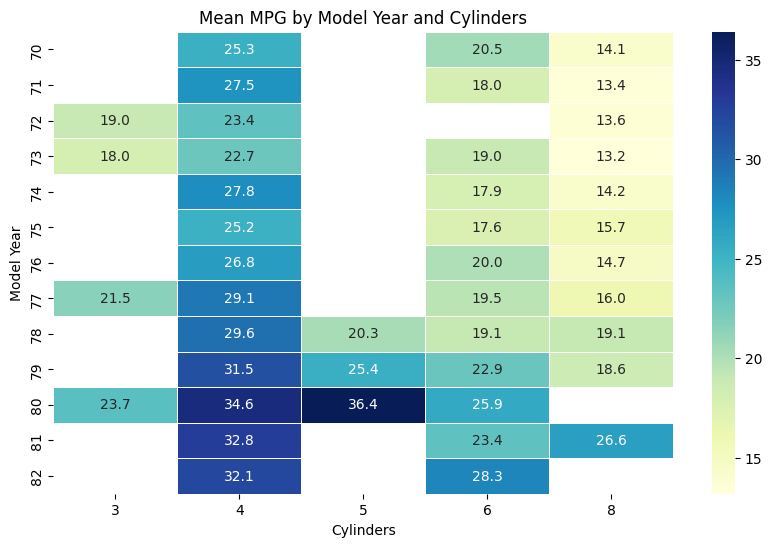

In [53]:
# Create pivot table: rows = model_year, columns = cylinders, values = mean mpg
pivot_table = df.pivot_table(values="mpg", index="model_year", columns="cylinders", aggfunc="mean")

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5)

plt.title("Mean MPG by Model Year and Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Model Year")
plt.show()

# Observ: 5cyl for 1980 gave handsome mileage